# Module 4: Deep Learning — Brain Tumor Classification
**Course**: Computer Vision | Christian Mata, PhD

**Dataset**: LGG Brain MRI Segmentation (Kaggle — mateuszbuda)

**Task**: Binary classification — does this MRI slice contain a tumor? (yes / no)

**Labels**: Derived from the segmentation masks — if any pixel in the mask is non-zero, the slice contains a tumor.

**Group members**: Martin Çaro, Edison Zyberaj

# Brain Tumor Classification
**Requires 01_train_test.** Loads pre-split data from Drive, trains CNN, saves model.

## 1. Mount Drive and check setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE = '/content/drive/MyDrive/CV_Project'
os.makedirs(DRIVE + '/brain/images', exist_ok=True)
os.makedirs(DRIVE + '/brain/masks',  exist_ok=True)
os.makedirs(DRIVE + '/splits',       exist_ok=True)
os.makedirs(DRIVE + '/models',       exist_ok=True)
os.makedirs(DRIVE + '/results',      exist_ok=True)
print('Drive mounted ✓  —  ' + DRIVE)

Mounted at /content/drive
Drive mounted ✓  —  /content/drive/MyDrive/CV_Project


In [2]:
import os, numpy as np
assert os.path.exists(DRIVE + '/splits/x_train.npy'),     '❌ Run 01_train_test.ipynb first.'
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

x_train = np.load(DRIVE + '/splits/x_train.npy')
x_test  = np.load(DRIVE + '/splits/x_test.npy')
y_train = np.load(DRIVE + '/splits/y_train.npy')
y_test  = np.load(DRIVE + '/splits/y_test.npy')

num_classes  = 2
input_shape  = (128, 128, 3)
label_names  = ['no tumor', 'tumor']

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

print(f'x_train: {x_train.shape}  |  x_test: {x_test.shape}')
print(f'Tumor in test set: {y_test.sum()}/{len(y_test)}')

x_train: (3143, 128, 128, 3)  |  x_test: (786, 128, 128, 3)
Tumor in test set: 276/786


## 2. Visualize one sample per class

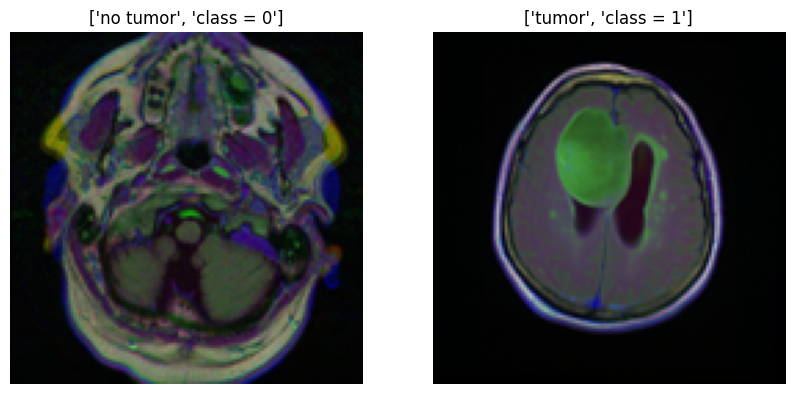

In [3]:
fig = plt.figure(figsize=(10, 5))
for kclass in range(2):
    ind = np.argwhere(y_train == kclass)
    ax  = fig.add_subplot(1, 2, kclass + 1)
    ax.imshow(x_train[ind[0][0]])
    ax.set_title([label_names[kclass], 'class = {}'.format(kclass)])
    ax.axis('off')

## 3. Build the CNN

In [4]:
model = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(name='features'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax'),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Flatten)              │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,578 (28.20 MB)

 Trainable params: 7,392,578 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Train

In [5]:
batch_size = 32
epochs     = 15

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train, y_train_cat, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.6637 - loss: 0.6125 - val_accuracy: 0.6984 - val_loss: 0.5037
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7458 - loss: 0.4845 - val_accuracy: 0.7714 - val_loss: 0.4703
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7825 - loss: 0.4430 - val_accuracy: 0.7841 - val_loss: 0.4310
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8052 - loss: 0.3946 - val_accuracy: 0.8317 - val_loss: 0.3912
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8289 - loss: 0.3565 - val_accuracy: 0.8603 - val_loss: 0.3431
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8575 - loss: 0.3216 - val_accuracy: 0.8635 - val_loss: 0.3449
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8833 - loss: 0.2844 - val_accuracy: 0.8476 - val_loss: 0.3579
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8978 - loss: 0.2542 - val_accuracy: 0.8762 - 

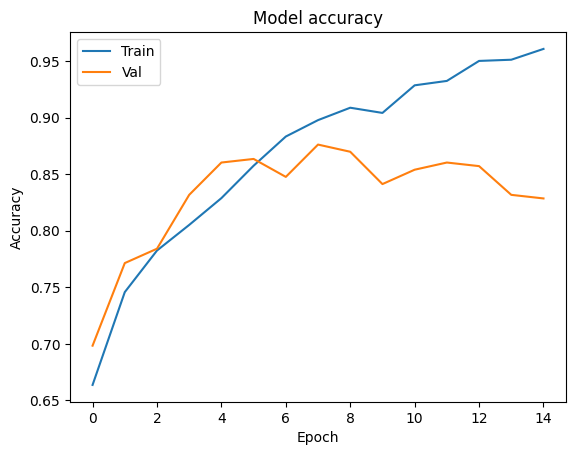

In [6]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy'); plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.savefig(DRIVE + '/results/classification_accuracy.png', dpi=120)
plt.show()

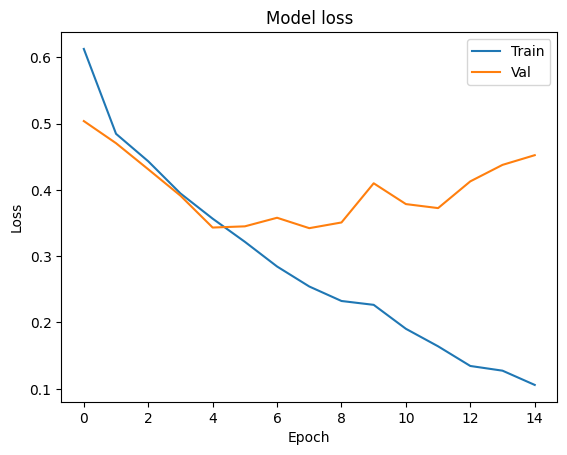

In [7]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss'); plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.savefig(DRIVE + '/results/classification_loss.png', dpi=120)
plt.show()

## 5. Evaluate

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

score = model.evaluate(x_test, y_test_cat, verbose=0)
print('Test loss:    ', score[0])
print('Test accuracy:', score[1])

y_test_pred = np.argmax(model.predict(x_test), axis=1)
print(classification_report(y_test, y_test_pred, target_names=label_names))
print(confusion_matrix(y_test, y_test_pred))

Test loss:     0.5425470471382141
Test accuracy: 0.8346055746078491
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

    no tumor       0.86      0.90      0.88       510
       tumor       0.79      0.72      0.75       276

    accuracy                           0.83       786
   macro avg       0.82      0.81      0.81       786
weighted avg       0.83      0.83      0.83       786

[[457  53]
 [ 77 199]]


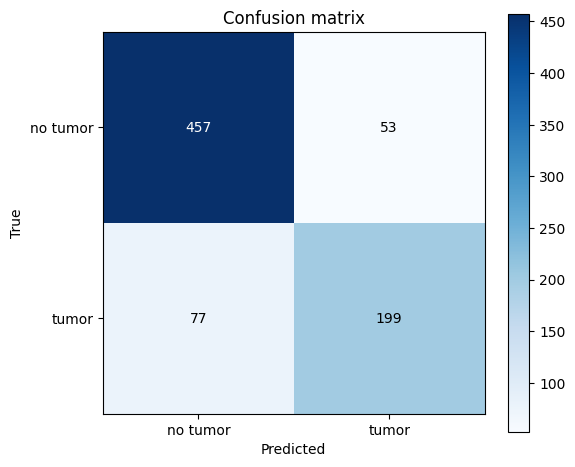

In [9]:
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set_xticks(np.arange(num_classes)); ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(label_names); ax.set_yticklabels(label_names)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2. else 'black')
ax.set_title('Confusion matrix'); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(DRIVE + '/results/confusion_matrix.png', dpi=120)
plt.show()

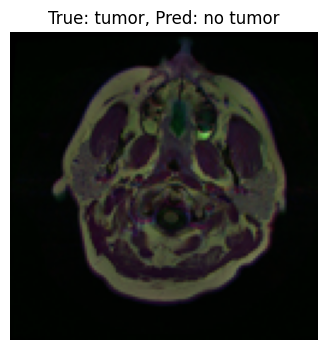

True: tumor | Pred: no tumor


In [10]:
isel = np.where((y_test == 1) & (y_test_pred == 0))[0]
if len(isel) > 0:
    idx = isel[0]
    plt.figure(figsize=(4, 4))
    plt.imshow(x_test[idx])
    plt.title('True: {}, Pred: {}'.format(label_names[y_test[idx]], label_names[y_test_pred[idx]]))
    plt.axis('off'); plt.show()
    print('True:', label_names[y_test[idx]], '| Pred:', label_names[y_test_pred[idx]])
else:
    print('No false negatives found.')

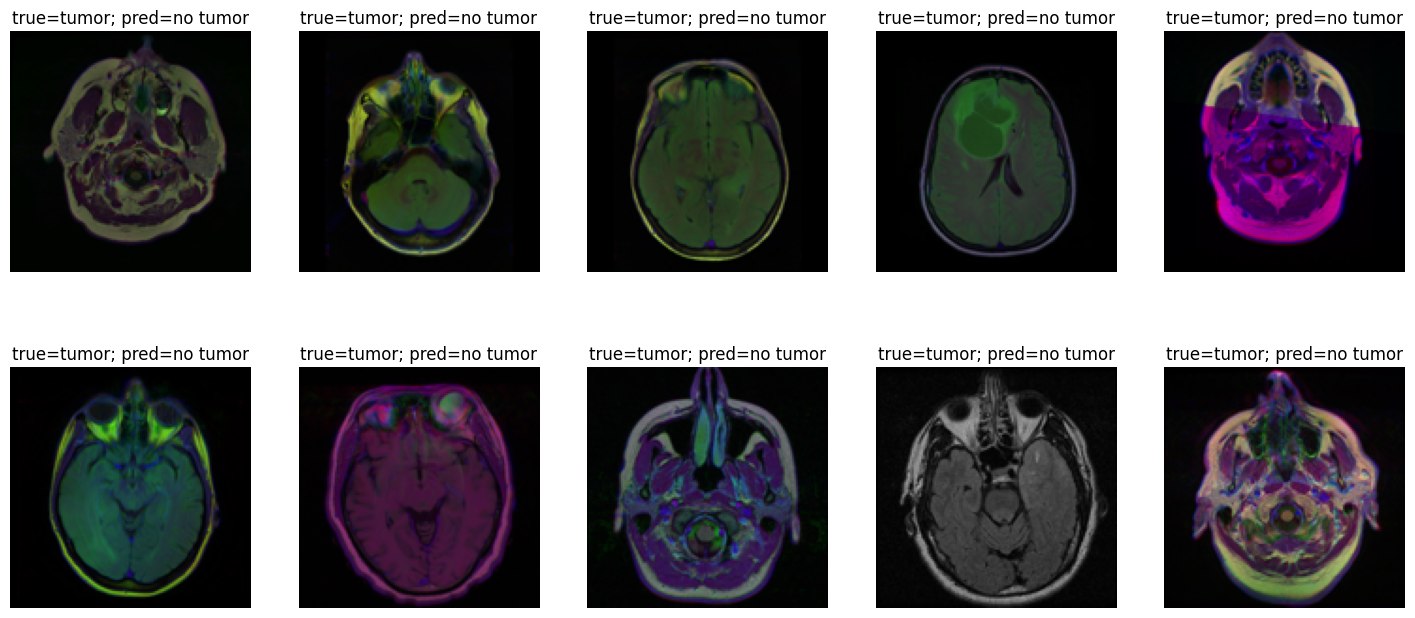

In [11]:
isel   = np.squeeze(np.where((y_test == 1) & (y_test_pred == 0)))
n_show = min(10, len(np.atleast_1d(isel)))
fig    = plt.figure(figsize=(18, 8))
cnt    = 0
for k in np.atleast_1d(isel)[:n_show]:
    cnt += 1
    ax = fig.add_subplot(2, 5, cnt)
    ax.imshow(x_test[k])
    ax.set_title('true={}; pred={}'.format(label_names[y_test[k]], label_names[y_test_pred[k]]))
    ax.axis('off')

## 6. Prediction probabilities

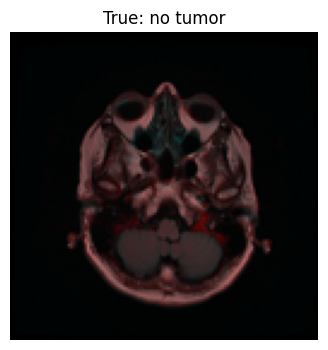

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step
Most likely:   no tumor -- P = 0.5875841
Second:        tumor -- P = 0.41241595


In [12]:
isel = 0
plt.figure(figsize=(4, 4))
plt.imshow(x_test[isel]); plt.title('True: ' + label_names[y_test[isel]])
plt.axis('off'); plt.show()

probabilities = model.predict(np.array([x_test[isel]]))
index         = np.argsort(probabilities[0, :])
print('Most likely:  ', label_names[index[1]], '-- P =', probabilities[0, index[1]])
print('Second:       ', label_names[index[0]], '-- P =', probabilities[0, index[0]])

## 7. Save model to Drive

In [14]:
model.save(DRIVE + '/models/brain_tumor_classifier.h5')
print('Model saved to Drive ✓')
from keras.models import load_model
loaded = load_model(DRIVE + '/models/brain_tumor_classifier.h5')
print('Reloaded. Accuracy:', loaded.evaluate(x_test, y_test_cat, verbose=0)[1])

Model saved to Drive ✓
Reloaded. Accuracy: 0.8346055746078491


## 8. Discussion

**Dataset.** The LGG Brain MRI Segmentation dataset contains 3929 MRI slices from 110 patients with lower-grade gliomas. Each slice has three MRI channels (pre-contrast, FLAIR, post-contrast) and a binary segmentation mask. Since no explicit classification labels are provided, we derive them from the masks: if any pixel in the mask is non-zero, the slice is labelled as containing a tumor. This gives a binary classification problem — tumor present vs absent.

**Class imbalance.** Most slices have no visible tumor (the tumor affects only part of the brain at any given cross-section). This imbalance makes classification harder: a model that always predicts 'no tumor' can achieve high accuracy but has no clinical value. The precision/recall per class in the classification report reveals whether the model handles this imbalance correctly.

**Model.** The CNN architecture is adapted for the 128×128×3 brain MRI input. The two convolutional blocks learn to detect local patterns (edges, textures, abnormal intensity regions), and the Dense layers classify the resulting features. The key difference from the class example is the input resolution: 128×128 instead of 28×28, which requires the convolutional blocks to process more spatial information.

**Clinical relevance.** False negatives (tumor predicted as no-tumor) are more dangerous than false positives in a medical screening context. This kind of error analysis is essential in medical AI and connects to the discussion of precision vs recall in the classification report.